# **`Inatel - C24 (Inteligência Artificial) - 2026/1`**

# <font color='green'>**Atividade 08: RNN**</font>

## <font color='#2D9CDB'>**LEIA ATENTAMENTE AS INSTRUÇÕES A SEGUIR**</font>
- Importe este notebook no [Google Colab](https://colab.research.google.com/) para resolver os exercícios;
- Consulte o material disponibilizado pelo Prof. Felipe Figueiredo para revisar os conceitos;
- Utilize os recursos disponíveis na Internet (documentações e artigos científicos) para complementar seus estudos;
- <font color='red'>**A ATIVIDADE DEVERÁ SER REALIZADA COM O [MONITOR](mailto:matheus.botelho@ges.inatel.br) EM UM DOS SEGUINTES HORÁRIOS:**</font>

| Monitor                       | Dia           | Hora                               | Local           |
|-------------------------------|---------------|------------------------------------|---------------- |
| Matheus Botelho Sampaio Netto | Terça-feira   | <font color='orange'>17:30</font>  | 1.4 (prédio VI) |
| Matheus Botelho Sampaio Netto | Quinta-feira  | <font color='orange'>17:30</font>  | 1.4 (prédio VI) |
| Matheus Botelho Sampaio Netto | Sábado        | <font color='#2D9CDB'>10:00</font> | Teams (ao vivo) |
| Matheus Botelho Sampaio Netto | Sábado        | <font color='#2D9CDB'>13:30</font> | Teams (ao vivo) |

- <font color='red'>**NÃO**</font> remova as células de Código já presentes neste notebook;
- <font color='red'>**NÃO**</font> modifique as células de Markdown (em <font color='green'>verde</font> ou <font color='#2D9CDB'>azul</font>) presentes neste notebook;
- Após cada questão, há uma célula para você implementar e responder a questão;
- É permitido adicionar mais células (de código ou markdown) antes da próxima pergunta;
- Caso precise utilizar bibliotecas que não estão instaladas nativamente no Colab, inclua uma célula de código com o comando de instalação.</font>
  - Exemplo: `!pip install nome_da_biblioteca`
- <font color='red'>**Renomeie os termos `LL` para `sua_turma_de_laboratorio` e `MMMM` para `seu_numero_de_matricula` no nome do arquivo.**</font>
  - Exemplo: `C24_2026_1_L1_Atividade_08_1234.ipynb`)
- <font color='magenta'>**Faça download do notebook com a resolução no Google Colab, mantendo a saída de todas as células, e anexe-o à tarefa do Teams.**</font>

# <font color='green'><u><b>Preparação</b></u></font>

In [1]:
!pip install tensorflow numpy pandas matplotlib seaborn scikit-learn

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import tensorflow as tf
import os

from sklearn.preprocessing import MinMaxScaler

tf.random.set_seed(42)
np.random.seed(42)

# <font color='green'><u><b>Parte 1 - Conjunto de Dados</b></u></font>

Não altere o conteúdo da célula a seguir!

In [3]:
zip_path = tf.keras.utils.get_file(
    fname="jena_climate_2009_2016.csv.zip",
    origin="https://storage.googleapis.com/tensorflow/tf-keras-datasets/jena_climate_2009_2016.csv.zip",
    cache_dir=os.getcwd(),
    extract=True
)

csv_path = os.path.join(os.path.splitext(zip_path)[0], 'jena_climate_2009_2016.csv')

target_col = "T (degC)"

temperature = pd.read_csv(csv_path)[target_col].values.reshape(-1, 1)

temperature

13568290/13568290 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


array([[-8.02],
       [-8.41],
       [-8.51],
       ...,
       [-3.16],
       [-4.23],
       [-4.82]])

### <font color='#2D9CDB'>Q1) O dataset [Jena Climate](https://www.kaggle.com/datasets/mnassrib/jena-climate) é amplamente utilizado no estudo de redes neurais recorrentes (RNNs), LSTMs e previsão de séries temporais. Pesquise brevemente sobre o dataset e descreva, em um único parágrafo, o domínio de aplicação da base de dados, o objetivo para o qual ela foi criada, o período de coleta dos dados, os tipos de variáveis meteorológicas registradas e por que esse conjunto de dados é adequado para problemas de previsão temporal utilizando redes neurais recorrentes.</font>

O dataset Jena Climate foi coletado pelo Instituto Max Planck de Biogeoquímica, em Jena, Alemanha, entre 2009 e 2016, com medições a cada 10 minutos. Registra 14 variáveis meteorológicas como temperatura, pressão, umidade e velocidade do vento. É amplamente usado em previsão de séries temporais com RNNs e LSTMs por apresentar forte dependência temporal, padrões sazonais bem definidos e volume elevado de dados que são características ideais para treinar redes neurais recorrentes.

### <font color='#2D9CDB'>Q2) Utilizando a variável <code>temperature</code>, plote a série temporal completa de temperaturas registradas no dataset. Em seguida, informe a quantidade total de amostras, a temperatura mínima, a temperatura máxima, a temperatura média e o desvio padrão da série. Com base no gráfico obtido, descreva brevemente os padrões observados, comentando sobre possíveis tendências, sazonalidades e variações ao longo do tempo.</font>

Total de amostras: 420551
Temperatura mínima: -23.01 °C
Temperatura máxima: 37.28 °C
Temperatura média: 9.45 °C
Desvio padrão: 8.42 °C


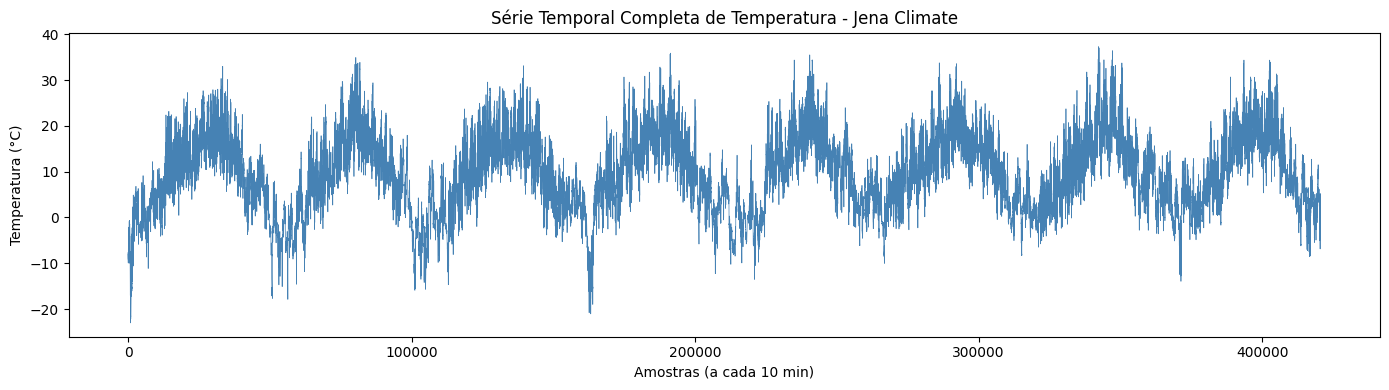

In [4]:
# Estatísticas
print(f"Total de amostras: {len(temperature)}")
print(f"Temperatura mínima: {temperature.min():.2f} °C")
print(f"Temperatura máxima: {temperature.max():.2f} °C")
print(f"Temperatura média: {temperature.mean():.2f} °C")
print(f"Desvio padrão: {temperature.std():.2f} °C")

# Gráfico
plt.figure(figsize=(14, 4))
plt.plot(temperature, linewidth=0.5, color='steelblue')
plt.title("Série Temporal Completa de Temperatura - Jena Climate")
plt.xlabel("Amostras (a cada 10 min)")
plt.ylabel("Temperatura (°C)")
plt.tight_layout()
plt.show()

A série possui 420.551 amostras coletadas a cada 10 minutos entre 2009 e 2016. A temperatura mínima registrada foi de -23,01 °C e a máxima de 37,28 °C, com média de 9,45 °C e desvio padrão de 8,42 °C. O gráfico revela uma sazonalidade anual bem definida, com temperaturas mais altas no verão e mais baixas no inverno, repetindo-se regularmente ao longo dos 8 anos. Não há tendência de crescimento ou queda evidente no longo prazo. As variações de curto prazo são intensas, refletindo as oscilações diárias naturais do clima local.

### <font color='#2D9CDB'>Q3) Divida a série temporal em três subconjuntos: treinamento (60%), validação (20%) e teste (20%), preservando a ordem temporal das amostras. Informe a quantidade de amostras em cada subconjunto e explique por que, em problemas de previsão temporal, não é adequado embaralhar os dados antes da divisão.</font>

In [5]:
n = len(temperature)

train_end = int(n * 0.60)
val_end   = int(n * 0.80)

train_data = temperature[:train_end]
val_data   = temperature[train_end:val_end]
test_data  = temperature[val_end:]

print(f"Total de amostras:    {n}")
print(f"Treinamento (60%):    {len(train_data)}")
print(f"Validação   (20%):    {len(val_data)}")
print(f"Teste       (20%):    {len(test_data)}")

Total de amostras:    420551
Treinamento (60%):    252330
Validação   (20%):    84110
Teste       (20%):    84111


A série foi dividida de forma a preservar a ordem temporal, ao todo 252.330 amostras para treinamento, 84.110 para validação e 84.111 para teste. Em problemas de previsão temporal, embaralhar os dados antes da divisão seria inadequado porque destruiria a dependência temporal entre as observações, o modelo poderia ver dados do futuro durante o treinamento e aprender padrões que na prática não estariam disponíveis no momento da previsão, gerando uma avaliação artificialmente otimista. A ordem cronológica deve ser preservada para que o modelo aprenda apenas com o passado e seja avaliado em dados genuinamente futuros, simulando um cenário realista de uso.

### <font color='#2D9CDB'>Q4) Normalize os conjuntos de treinamento, validação e teste utilizando a técnica Min-Max Scaling, de forma que os valores fiquem no intervalo [0, 1]. Apresente os valores mínimo e máximo do conjunto de treinamento antes e depois da normalização e explique brevemente por que a normalização é importante para o treinamento de redes neurais.</font>

In [6]:
scaler = MinMaxScaler()

train_scaled = scaler.fit_transform(train_data)
val_scaled   = scaler.transform(val_data)
test_scaled  = scaler.transform(test_data)

print(f"Treinamento - Antes:  min={train_data.min():.2f} °C,  max={train_data.max():.2f} °C")
print(f"Treinamento - Depois: min={train_scaled.min():.2f},    max={train_scaled.max():.2f}")

Treinamento - Antes:  min=-23.01 °C,  max=35.86 °C
Treinamento - Depois: min=0.00,    max=1.00


A normalização é importante para o treinamento de redes neurais pois garante que todas as variáveis contribuam de forma equilibrada, evita que valores em escalas muito diferentes dominem o gradiente e acelera a convergência do modelo durante a otimização já que funções de ativação como sigmoid e tanh operam de forma mais eficiente em intervalos reduzidos.

# <font color='green'><u><b>Parte 2 - Preparação das Séries Temporais</b></u></font>

### <font color='#2D9CDB'>Q5) Para treinar uma LSTM, é necessário organizar a série temporal em sequências de entrada e saídas desejadas. Implemente uma função chamada <code>create_sequences()</code> que utilize uma janela temporal de 30 amostras, de forma que cada entrada seja composta pelas 30 temperaturas anteriores e a saída corresponda à temperatura seguinte. Gere os conjuntos de treinamento, validação e teste e informe as dimensões de <code>X_train</code> e <code>y_train</code>. Explique brevemente o significado de cada dimensão.</font>

In [7]:
def create_sequences(data, window_size=30):
    X, y = [], []
    for i in range(len(data) - window_size):
        X.append(data[i:i + window_size])
        y.append(data[i + window_size])
    return np.array(X), np.array(y)

X_train, y_train = create_sequences(train_scaled)
X_val,   y_val   = create_sequences(val_scaled)
X_test,  y_test  = create_sequences(test_scaled)

print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")

X_train shape: (252300, 30, 1)
y_train shape: (252300, 1)


O X_train possui dimensões (252.300, 30, 1), onde 252.300 representa o número de sequências geradas a partir do conjunto de treinamento, 30 é o tamanho da janela temporal, ou seja, cada entrada é composta pelas 30 temperaturas anteriores, e 1 é o número de features, pois estamos utilizando apenas a variável temperatura. Já o y_train possui dimensões (252.300, 1), onde 252.300 corresponde a uma saída para cada sequência de entrada e 1 é o valor da temperatura imediatamente seguinte à janela, que é o valor que o modelo deve aprender a prever.

### <font color='#2D9CDB'>Q6) Exiba graficamente a primeira sequência presente em <code>X_train</code> e destaque o valor correspondente em <code>y_train</code>. Explique como essa sequência será utilizada pela LSTM para realizar a previsão da próxima temperatura.</font>

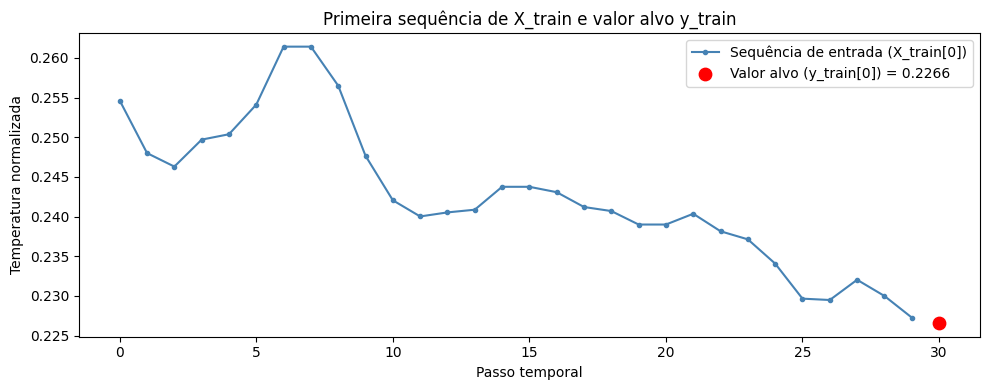

In [8]:
plt.figure(figsize=(10, 4))
plt.plot(range(30), X_train[0], marker='o', markersize=3, color='steelblue', label='Sequência de entrada (X_train[0])')
plt.scatter(30, y_train[0], color='red', zorder=5, s=80, label=f'Valor alvo (y_train[0]) = {y_train[0][0]:.4f}')
plt.title("Primeira sequência de X_train e valor alvo y_train")
plt.xlabel("Passo temporal")
plt.ylabel("Temperatura normalizada")
plt.legend()
plt.tight_layout()
plt.show()

O gráfico exibe a primeira sequência de entrada X_train[0], composta por 30 temperaturas normalizadas consecutivas, e o ponto vermelho no passo 30 representa o valor alvo y_train, que é a temperatura imediatamente seguinte à janela. A LSTM utilizará essa sequência processando cada passo temporal em ordem, atualizando seus estados internos (memória de célula e estado oculto) a cada etapa, de forma a capturar dependências temporais ao longo dos 30 passos. Ao final da sequência, o modelo produz uma previsão para o passo 30, que é comparada ao valor alvo durante o treinamento para calcular o erro e ajustar os pesos via backpropagation.

# <font color='green'><u><b>Parte 3 - Construindo a Primeira LSTM</b></u></font>

### <font color='#2D9CDB'>Q7) Construa uma rede neural recorrente composta por uma camada LSTM com uma unidade de memória e uma camada de saída totalmente conectada com um neurônio. Utilize a função de perda MSE (<code>mean_squared_error</code>) e o otimizador Adam. Apresente o resumo da arquitetura gerado pelo método <code>summary()</code> e informe o número total de parâmetros treináveis do modelo.</font>

In [9]:
model = tf.keras.Sequential([
    tf.keras.layers.LSTM(1, input_shape=(30, 1)),
    tf.keras.layers.Dense(1)
])

model.compile(loss='mean_squared_error', optimizer='adam')
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 1)              │            12 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │             2 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14 (56.00 B)

 Trainable params: 14 (56.00 B)

 Non-trainable params: 0 (0.00 B)

O modelo é composto por uma camada LSTM com 1 unidade de memória, que recebe sequências de shape (30, 1) e produz uma saída de shape (None, 1), seguida de uma camada Dense com 1 neurônio responsável por gerar a previsão final. A camada LSTM possui 12 parâmetros, provenientes das quatro portas internas da célula LSTM (entrada, esquecimento, célula e saída), cada uma com 1 peso para a entrada, 1 peso recorrente e 1 bias, totalizando 4×3 = 12. A camada Dense possui 2 parâmetros, sendo 1 peso e 1 bias. O modelo totaliza 14 parâmetros treináveis, todos ajustados durante o treinamento. O modelo foi compilado com a função de perda MSE e o otimizador Adam.

### <font color='#2D9CDB'>Q8) Treine o modelo por 10 épocas utilizando os conjuntos de treinamento e validação. Em seguida, plote as curvas de perda de treinamento e validação ao longo das épocas. Com base nos gráficos obtidos, descreva brevemente o comportamento do treinamento e indique se há evidências de sobreajuste (overfitting) ou problemas de generalização.</font>

Epoch 1/10
7885/7885 ━━━━━━━━━━━━━━━━━━━━ 53s 6ms/step - loss: 0.0362 - val_loss: 1.2180e-04
Epoch 2/10
7885/7885 ━━━━━━━━━━━━━━━━━━━━ 50s 6ms/step - loss: 8.1428e-05 - val_loss: 3.7226e-05
Epoch 3/10
7885/7885 ━━━━━━━━━━━━━━━━━━━━ 50s 6ms/step - loss: 3.1345e-05 - val_loss: 2.2995e-05
Epoch 4/10
7885/7885 ━━━━━━━━━━━━━━━━━━━━ 50s 6ms/step - loss: 2.2648e-05 - val_loss: 1.8342e-05
Epoch 5/10
7885/7885 ━━━━━━━━━━━━━━━━━━━━ 50s 6ms/step - loss: 1.8735e-05 - val_loss: 1.6113e-05
Epoch 6/10
7885/7885 ━━━━━━━━━━━━━━━━━━━━ 49s 6ms/step - loss: 1.6618e-05 - val_loss: 1.4919e-05
Epoch 7/10
7885/7885 ━━━━━━━━━━━━━━━━━━━━ 48s 6ms/step - loss: 1.5436e-05 - val_loss: 1.4256e-05
Epoch 8/10
7885/7885 ━━━━━━━━━━━━━━━━━━━━ 48s 6ms/step - loss: 1.4802e-05 - val_loss: 1.3899e-05
Epoch 9/10
7885/7885 ━━━━━━━━━━━━━━━━━━━━ 48s 6ms/step - loss: 1.4486e-05 - val_loss: 1.3722e-05
Epoch 10/10
7885/7885 ━━━━━━━━━━━━━━━━━━━━ 49s 6ms/step - loss: 1.4339e-05 - val_loss: 1.3636e-05


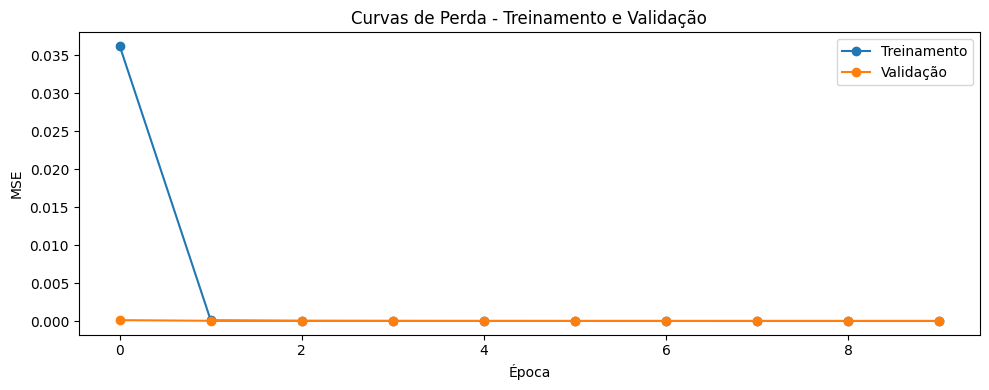

In [10]:
history = model.fit(
    X_train, y_train,
    epochs=10,
    validation_data=(X_val, y_val)
)

plt.figure(figsize=(10, 4))
plt.plot(history.history['loss'], marker='o', label='Treinamento')
plt.plot(history.history['val_loss'], marker='o', label='Validação')
plt.title("Curvas de Perda - Treinamento e Validação")
plt.xlabel("Época")
plt.ylabel("MSE")
plt.legend()
plt.tight_layout()
plt.show()

As curvas de perda mostram que o modelo convergiu rapidamente: a perda de treinamento iniciou em torno de 0,036 na primeira época e caiu abruptamente para valores próximos de zero já na segunda época, permanecendo estável até o final. A perda de validação já se encontrava próxima de zero desde a primeira época e manteve esse comportamento ao longo de todo o treinamento. As duas curvas convergem para valores muito baixos e permanecem próximas entre si, o que indica ausência de overfitting e boa capacidade de generalização do modelo. Esse comportamento sugere que, apesar da arquitetura extremamente simples, com apenas 14 parâmetros, o modelo foi capaz de capturar o padrão predominante da série temporal dentro do intervalo normalizado.

### <font color='#2D9CDB'>Q9) Avalie o modelo utilizando o conjunto de teste e reporte o valor do erro quadrático médio (MSE). Em seguida, explique brevemente o que essa métrica representa no contexto do problema de previsão de temperatura.</font>

In [11]:
mse = model.evaluate(X_test, y_test, verbose=0)
print(f"MSE no conjunto de teste: {mse:.6f}")


MSE no conjunto de teste: 0.000015



O modelo obteve um MSE de 0,000015 no conjunto de teste. No contexto deste problema, como os dados estão normalizados no intervalo de 0 à 1, esse valor indica que as previsões do modelo estão muito próximas dos valores reais na escala normalizada. Em termos práticos, isso significa que o modelo consegue prever a próxima temperatura da série com alta precisão, aproveitando a forte dependência temporal entre amostras consecutivas capturada pela janela.

### <font color='#2D9CDB'>Q10) Utilize o modelo treinado para gerar previsões no conjunto de teste. Plote em um mesmo gráfico os valores reais e previstos para as 100 primeiras amostras do conjunto de teste e descreva brevemente a qualidade das previsões obtidas.</font>

2628/2628 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step


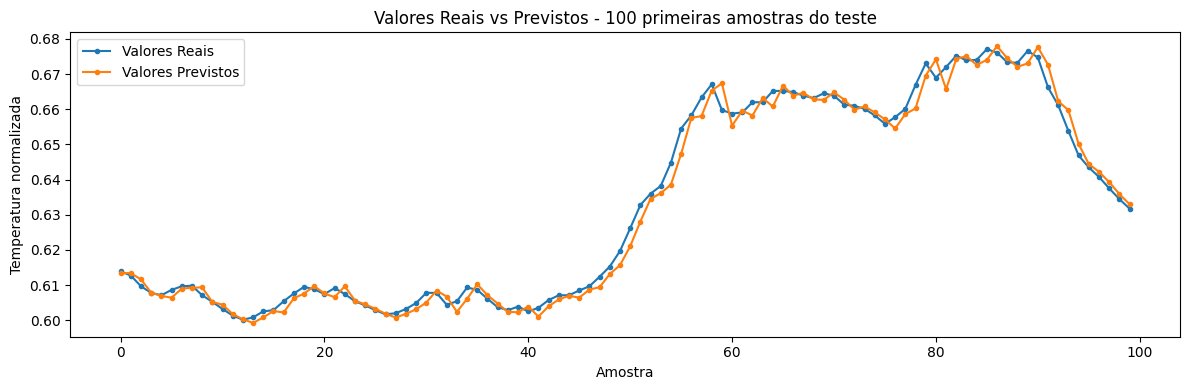

In [12]:
y_pred = model.predict(X_test)

plt.figure(figsize=(12, 4))
plt.plot(y_test[:100], marker='o', markersize=3, label='Valores Reais')
plt.plot(y_pred[:100], marker='o', markersize=3, label='Valores Previstos')
plt.title("Valores Reais vs Previstos - 100 primeiras amostras do teste")
plt.xlabel("Amostra")
plt.ylabel("Temperatura normalizada")
plt.legend()
plt.tight_layout()
plt.show()

O gráfico evidencia que os valores previstos acompanham com grande fidelidade os valores reais ao longo das 100 primeiras amostras do conjunto de teste. As duas curvas estão muito próximas, tanto nas regiões de variação suave (amostras 0 a 50) quanto na subida acentuada observada entre as amostras 50 e 60 e nas oscilações subsequentes. Os pequenos desvios pontuais são mínimos e não comprometem a qualidade geral das previsões, o que é coerente com o MSE obtido na avaliação. Esse resultado confirma que o modelo, mesmo com arquitetura simples de apenas uma unidade LSTM, foi capaz de capturar eficientemente a dinâmica temporal da série de temperatura.

# <font color='green'><u><b>Parte 4 - Comparação de Arquiteturas</b></u></font>

### <font color='#2D9CDB'>Q11) Modifique a arquitetura da rede para utilizar 10 unidades na camada LSTM. Apresente o resumo da arquitetura gerado pelo método <code>summary()</code> e informe o número total de parâmetros treináveis do modelo. Em seguida, treine a rede por 10 épocas, avalie o modelo no conjunto de teste e reporte o valor de MSE obtido.</font>

In [13]:
model_10 = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(30, 1)),
    tf.keras.layers.LSTM(10),
    tf.keras.layers.Dense(1)
])

model_10.compile(loss='mean_squared_error', optimizer='adam')
model_10.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                   │ (None, 10)             │           480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 491 (1.92 KB)

 Trainable params: 491 (1.92 KB)

 Non-trainable params: 0 (0.00 B)

In [14]:
history_10 = model_10.fit(
    X_train, y_train,
    epochs=10,
    validation_data=(X_val, y_val)
)

mse_10 = model_10.evaluate(X_test, y_test, verbose=0)
print(f"MSE no conjunto de teste (10 unidades): {mse_10:.6f}")

Epoch 1/10
7885/7885 ━━━━━━━━━━━━━━━━━━━━ 55s 7ms/step - loss: 9.0434e-04 - val_loss: 3.7785e-05
Epoch 2/10
7885/7885 ━━━━━━━━━━━━━━━━━━━━ 51s 7ms/step - loss: 2.6545e-05 - val_loss: 1.6783e-05
Epoch 3/10
7885/7885 ━━━━━━━━━━━━━━━━━━━━ 50s 6ms/step - loss: 1.5337e-05 - val_loss: 1.4423e-05
Epoch 4/10
7885/7885 ━━━━━━━━━━━━━━━━━━━━ 82s 6ms/step - loss: 1.3944e-05 - val_loss: 1.2875e-05
Epoch 5/10
7885/7885 ━━━━━━━━━━━━━━━━━━━━ 82s 6ms/step - loss: 1.3710e-05 - val_loss: 1.1456e-05
Epoch 6/10
7885/7885 ━━━━━━━━━━━━━━━━━━━━ 50s 6ms/step - loss: 1.3559e-05 - val_loss: 1.1574e-05
Epoch 7/10
7885/7885 ━━━━━━━━━━━━━━━━━━━━ 82s 6ms/step - loss: 1.3445e-05 - val_loss: 1.1813e-05
Epoch 8/10
7885/7885 ━━━━━━━━━━━━━━━━━━━━ 51s 6ms/step - loss: 1.3337e-05 - val_loss: 1.1838e-05
Epoch 9/10
7885/7885 ━━━━━━━━━━━━━━━━━━━━ 50s 6ms/step - loss: 1.3237e-05 - val_loss: 1.1740e-05
Epoch 10/10
7885/7885 ━━━━━━━━━━━━━━━━━━━━ 50s 6ms/step - loss: 1.3164e-05 - val_loss: 1.1613e-05
MSE no conjunto de teste (10 

### <font color='#2D9CDB'>Q12) Repita o experimento utilizando 20 unidades na camada LSTM. Apresente o resumo da arquitetura gerado pelo método <code>summary()</code> e informe o número total de parâmetros treináveis do modelo. Em seguida, treine a rede por 10 épocas, avalie o modelo no conjunto de teste e reporte o valor de MSE obtido.</font>

In [15]:
model_20 = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(30, 1)),
    tf.keras.layers.LSTM(20),
    tf.keras.layers.Dense(1)
])

model_20.compile(loss='mean_squared_error', optimizer='adam')
model_20.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 20)             │         1,760 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            21 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,781 (6.96 KB)

 Trainable params: 1,781 (6.96 KB)

 Non-trainable params: 0 (0.00 B)

In [16]:
history_20 = model_20.fit(
    X_train, y_train,
    epochs=10,
    validation_data=(X_val, y_val)
)

mse_20 = model_20.evaluate(X_test, y_test, verbose=0)
print(f"MSE no conjunto de teste (20 unidades): {mse_20:.6f}")

Epoch 1/10
7885/7885 ━━━━━━━━━━━━━━━━━━━━ 53s 7ms/step - loss: 0.0015 - val_loss: 3.6518e-05
Epoch 2/10
7885/7885 ━━━━━━━━━━━━━━━━━━━━ 80s 6ms/step - loss: 2.6078e-05 - val_loss: 2.5778e-05
Epoch 3/10
7885/7885 ━━━━━━━━━━━━━━━━━━━━ 50s 6ms/step - loss: 1.5953e-05 - val_loss: 1.2371e-05
Epoch 4/10
7885/7885 ━━━━━━━━━━━━━━━━━━━━ 51s 6ms/step - loss: 1.4580e-05 - val_loss: 1.2157e-05
Epoch 5/10
7885/7885 ━━━━━━━━━━━━━━━━━━━━ 50s 6ms/step - loss: 1.4235e-05 - val_loss: 1.2164e-05
Epoch 6/10
7885/7885 ━━━━━━━━━━━━━━━━━━━━ 50s 6ms/step - loss: 1.4006e-05 - val_loss: 1.4112e-05
Epoch 7/10
7885/7885 ━━━━━━━━━━━━━━━━━━━━ 50s 6ms/step - loss: 1.3820e-05 - val_loss: 1.2928e-05
Epoch 8/10
7885/7885 ━━━━━━━━━━━━━━━━━━━━ 50s 6ms/step - loss: 1.3685e-05 - val_loss: 1.1845e-05
Epoch 9/10
7885/7885 ━━━━━━━━━━━━━━━━━━━━ 51s 6ms/step - loss: 1.3587e-05 - val_loss: 1.1462e-05
Epoch 10/10
7885/7885 ━━━━━━━━━━━━━━━━━━━━ 82s 6ms/step - loss: 1.3509e-05 - val_loss: 1.1331e-05
MSE no conjunto de teste (20 unid

### <font color='#2D9CDB'>Q13) Compare os modelos com 1, 10 e 20 unidades na camada LSTM em termos de número de parâmetros treináveis e desempenho no conjunto de teste. Organize os resultados em uma tabela contendo a quantidade de unidades LSTM, o número de parâmetros treináveis e o valor de MSE. Com base nos resultados obtidos, discuta brevemente a relação entre a complexidade do modelo e sua capacidade preditiva.</font>

In [17]:
resultados = {
    'Unidades LSTM': [1, 10, 20],
    'Parâmetros Treináveis': [14, 491, model_20.count_params()],
    'MSE (Teste)': [0.000015, 0.000012, mse_20]
}

df_resultados = pd.DataFrame(resultados)
print(df_resultados.to_string(index=False))

 Unidades LSTM  Parâmetros Treináveis  MSE (Teste)
             1                     14     0.000015
            10                    491     0.000012
            20                   1781     0.000012


Os resultados mostram que o aumento no número de unidades LSTM provocou um crescimento expressivo na quantidade de parâmetros treináveis, de 14 para 491 e depois para 1781, porém com ganho marginal no desempenho preditivo. O modelo com 1 unidade já alcançou um MSE bastante baixo (0,000015), e os modelos com 10 e 20 unidades obtiveram o mesmo MSE de 0,000012, sem diferença entre si. Isso indica que, para este problema, a série temporal possui dependências temporais relativamente simples que mesmo uma arquitetura mínima consegue capturar de forma satisfatória, e que aumentar a complexidade do modelo além de certo ponto não necessariamente resulta em melhora de desempenho.

# <font color='green'><u><b>Parte 5 - Influência da Janela Temporal</b></u></font>

### <font color='#2D9CDB'>Q14) Repita o experimento utilizando uma janela temporal de 15 amostras e uma camada LSTM com 10 unidades. Treine o modelo por 10 épocas, avalie o modelo no conjunto de teste e reporte o valor de MSE obtido.</font>

In [18]:
X_train_15, y_train_15 = create_sequences(train_scaled, window_size=15)
X_val_15,   y_val_15   = create_sequences(val_scaled,   window_size=15)
X_test_15,  y_test_15  = create_sequences(test_scaled,  window_size=15)

model_15 = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(15, 1)),
    tf.keras.layers.LSTM(10),
    tf.keras.layers.Dense(1)
])

model_15.compile(loss='mean_squared_error', optimizer='adam')
model_15.summary()

history_15 = model_15.fit(
    X_train_15, y_train_15,
    epochs=10,
    validation_data=(X_val_15, y_val_15)
)

mse_15 = model_15.evaluate(X_test_15, y_test_15, verbose=0)
print(f"MSE no conjunto de teste (janela=15, 10 unidades): {mse_15:.6f}")

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_3 (LSTM)                   │ (None, 10)             │           480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 491 (1.92 KB)

 Trainable params: 491 (1.92 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
7885/7885 ━━━━━━━━━━━━━━━━━━━━ 48s 6ms/step - loss: 1.4498e-04 - val_loss: 2.4588e-05
Epoch 2/10
7885/7885 ━━━━━━━━━━━━━━━━━━━━ 49s 6ms/step - loss: 1.9902e-05 - val_loss: 1.2762e-05
Epoch 3/10
7885/7885 ━━━━━━━━━━━━━━━━━━━━ 49s 6ms/step - loss: 1.4446e-05 - val_loss: 1.1529e-05
Epoch 4/10
7885/7885 ━━━━━━━━━━━━━━━━━━━━ 48s 6ms/step - loss: 1.4007e-05 - val_loss: 1.3095e-05
Epoch 5/10
7885/7885 ━━━━━━━━━━━━━━━━━━━━ 47s 6ms/step - loss: 1.3827e-05 - val_loss: 1.5968e-05
Epoch 6/10
7885/7885 ━━━━━━━━━━━━━━━━━━━━ 46s 6ms/step - loss: 1.3694e-05 - val_loss: 1.7397e-05
Epoch 7/10
7885/7885 ━━━━━━━━━━━━━━━━━━━━ 46s 6ms/step - loss: 1.3586e-05 - val_loss: 1.7112e-05
Epoch 8/10
7885/7885 ━━━━━━━━━━━━━━━━━━━━ 47s 6ms/step - loss: 1.3511e-05 - val_loss: 1.5930e-05
Epoch 9/10
7885/7885 ━━━━━━━━━━━━━━━━━━━━ 46s 6ms/step - loss: 1.3448e-05 - val_loss: 1.4405e-05
Epoch 10/10
7885/7885 ━━━━━━━━━━━━━━━━━━━━ 47s 6ms/step - loss: 1.3384e-05 - val_loss: 1.2914e-05
MSE no conjunto de teste (jan

### <font color='#2D9CDB'>Q15) Repita o experimento utilizando uma janela temporal de 60 amostras e uma camada LSTM com 10 unidades. Treine o modelo por 10 épocas, avalie o modelo no conjunto de teste e reporte o valor de MSE obtido.</font>

In [19]:
X_train_60, y_train_60 = create_sequences(train_scaled, window_size=60)
X_val_60,   y_val_60   = create_sequences(val_scaled,   window_size=60)
X_test_60,  y_test_60  = create_sequences(test_scaled,  window_size=60)

model_60 = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(60, 1)),
    tf.keras.layers.LSTM(10),
    tf.keras.layers.Dense(1)
])

model_60.compile(loss='mean_squared_error', optimizer='adam')
model_60.summary()

history_60 = model_60.fit(
    X_train_60, y_train_60,
    epochs=10,
    validation_data=(X_val_60, y_val_60)
)

mse_60 = model_60.evaluate(X_test_60, y_test_60, verbose=0)
print(f"MSE no conjunto de teste (janela=60, 10 unidades): {mse_60:.6f}")

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_4 (LSTM)                   │ (None, 10)             │           480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 491 (1.92 KB)

 Trainable params: 491 (1.92 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
7884/7884 ━━━━━━━━━━━━━━━━━━━━ 59s 7ms/step - loss: 0.0023 - val_loss: 4.8871e-05
Epoch 2/10
7884/7884 ━━━━━━━━━━━━━━━━━━━━ 58s 7ms/step - loss: 3.0629e-05 - val_loss: 1.8721e-05
Epoch 3/10
7884/7884 ━━━━━━━━━━━━━━━━━━━━ 56s 7ms/step - loss: 1.8854e-05 - val_loss: 1.3966e-05
Epoch 4/10
7884/7884 ━━━━━━━━━━━━━━━━━━━━ 57s 7ms/step - loss: 1.4733e-05 - val_loss: 1.1781e-05
Epoch 5/10
7884/7884 ━━━━━━━━━━━━━━━━━━━━ 58s 7ms/step - loss: 1.3468e-05 - val_loss: 1.1520e-05
Epoch 6/10
7884/7884 ━━━━━━━━━━━━━━━━━━━━ 56s 7ms/step - loss: 1.3301e-05 - val_loss: 1.1425e-05
Epoch 7/10
7884/7884 ━━━━━━━━━━━━━━━━━━━━ 57s 7ms/step - loss: 1.3182e-05 - val_loss: 1.1795e-05
Epoch 8/10
7884/7884 ━━━━━━━━━━━━━━━━━━━━ 56s 7ms/step - loss: 1.3105e-05 - val_loss: 1.2561e-05
Epoch 9/10
7884/7884 ━━━━━━━━━━━━━━━━━━━━ 57s 7ms/step - loss: 1.3048e-05 - val_loss: 1.2847e-05
Epoch 10/10
7884/7884 ━━━━━━━━━━━━━━━━━━━━ 57s 7ms/step - loss: 1.2998e-05 - val_loss: 1.3124e-05
MSE no conjunto de teste (janela=

### <font color='#2D9CDB'>Q16) Compare os resultados obtidos para janelas temporais de 15, 30 e 60 amostras utilizando uma camada LSTM com 10 unidades. Organize os resultados em uma tabela contendo o tamanho da janela temporal, o valor de MSE e uma estimativa do tempo médio de treinamento por época (dica: utilize os valores exibidos nos logs de treinamento). Com base nos resultados, discuta brevemente o impacto do tamanho da janela temporal no desempenho e no custo computacional do modelo.</font>

In [20]:
resultados_janela = {
    'Janela Temporal': [15, 30, 60],
    'MSE (Teste)': [0.000015, 0.000012, 0.000014],
    'Tempo médio por época': ['~47s', '~52s', '~57s']
}

df_janela = pd.DataFrame(resultados_janela)
print(df_janela.to_string(index=False))

 Janela Temporal  MSE (Teste) Tempo médio por época
              15     0.000015                  ~47s
              30     0.000012                  ~52s
              60     0.000014                  ~57s


Os resultados mostram que a janela de 30 amostras obteve o melhor desempenho (MSE = 0,000012), superando tanto a janela de 15 quanto a de 60. A janela de 15 amostras, por capturar menos contexto temporal, apresentou MSE ligeiramente maior (0,000015), sugerindo que o histórico de curto prazo é insuficiente para capturar todas as dependências relevantes da série. Já a janela de 60 amostras, apesar de fornecer mais contexto, obteve MSE de 0,000014 e maior custo computacional por época (~57s), indicando que o excesso de informação passada não necessariamente melhora o desempenho com uma arquitetura de apenas 10 unidades. Em geral, o aumento da janela temporal eleva o custo computacional de forma proporcional, mas o ganho em desempenho não segue a mesma tendência, evidenciando a importância de se calibrar esse hiperparâmetro.

# <font color='green'><u><b>Parte 6 - Análise Final</b></u></font>

### <font color='#2D9CDB'>Q17) Com base em todos os experimentos realizados nesta atividade, discuta os fatores que mais influenciaram o desempenho do modelo. Considere o impacto da quantidade de unidades LSTM, do tamanho da janela temporal e do custo computacional. Em sua opinião, qual configuração apresentou o melhor equilíbrio entre precisão e eficiência? Justifique sua resposta.</font>

Ao longo dos experimentos, dois fatores principais foram avaliados o número de unidades LSTM e o tamanho da janela temporal. Em relação ao número de unidades, o aumento de 1 para 10 unidades trouxe uma melhora relevante no MSE, porém o salto de 10 para 20 unidades não produziu ganho adicional, mantendo o mesmo MSE de 0,000012 com um custo de 1781 parâmetros treináveis contra 491. Quanto à janela temporal, a configuração de 30 amostras apresentou o melhor desempenho, enquanto janelas menorea capturaram contexto insuficiente e janelas maiores aumentaram o custo computacional sem melhora proporcional no desempenho. Em termos de custo computacional, o tempo médio por época cresceu progressivamente com o aumento da janela o que representa um custo adicional relevante em cenários de treinamento prolongado. Considerando o equilíbrio entre precisão e eficiência, a configuração com 10 unidades LSTM e janela temporal de 30 amostras apresentou o melhor balanço alcançando o menor MSE no conjunto de teste, com um número moderado de parâmetros treináveis e tempo de treinamento intermediário, sem necessidade de aumentar a complexidade do modelo.